# Linear Regression

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df= pd.read_csv('Algerian_forest_fires_dataset.csv')

In [3]:
df

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,23/07/2012,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,07/06/2012,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,16/07/2012,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,29/08/2012,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [4]:
df.head()

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [5]:
df.shape

(244, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Date     244 non-null    object 
 2   Temp     244 non-null    int64  
 3   RH       244 non-null    int64  
 4   Ws       244 non-null    int64  
 5   Rain     244 non-null    float64
 6   FFMC     244 non-null    float64
 7   DMC      244 non-null    float64
 8   DC       244 non-null    float64
 9   ISI      244 non-null    float64
 10  BUI      244 non-null    float64
 11  FWI      244 non-null    float64
 12  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(2)
memory usage: 24.9+ KB


## Data Cleaning

In [7]:
df.isnull().sum()

Region     0
Date       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]   # Data missing check

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [9]:
df['Region'] = df['Region'].replace({
    'Bejaia': 0,
    'Sidi-Bel Abbes': 1
})

print(df.head())

   Region        Date  Temp  RH  Ws  Rain  FFMC   DMC     DC   ISI   BUI  \
0       0  12/06/2012    23  86   8  16.6  31.7   3.8   18.8   1.5   4.5   
1       0  03/06/2012    24  82  11  13.8  38.3  11.6   38.4   3.2  11.8   
2       1  16/08/2012    36  48  22   6.1  69.1  42.7  146.5  12.6  44.2   
3       1  14/09/2012    41  24  28   0.6  90.4  63.1  211.0  18.2  65.9   
4       1  07/09/2012    37  33  24   2.7  81.9  52.9  179.5  15.1  55.9   

    FWI   Classes  
0   1.8  Not Fire  
1   4.7  Not Fire  
2  20.2      Fire  
3  29.9      Fire  
4  25.4  Not Fire  


In [10]:
df.head()

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [11]:
df

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,23/07/2012,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,07/06/2012,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,16/07/2012,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,29/08/2012,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [12]:
df

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,23/07/2012,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,07/06/2012,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,16/07/2012,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,29/08/2012,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [13]:
df.head()

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [14]:
df.tail()

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
239,0,23/07/2012,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,07/06/2012,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,16/07/2012,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,29/08/2012,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire
243,0,21/07/2012,29,63,15,11.0,53.6,26.6,90.0,6.7,27.9,12.2,Not Fire


In [15]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Date     244 non-null    object 
 2   Temp     244 non-null    int64  
 3   RH       244 non-null    int64  
 4   Ws       244 non-null    int64  
 5   Rain     244 non-null    float64
 6   FFMC     244 non-null    float64
 7   DMC      244 non-null    float64
 8   DC       244 non-null    float64
 9   ISI      244 non-null    float64
 10  BUI      244 non-null    float64
 11  FWI      244 non-null    float64
 12  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(2)
memory usage: 24.9+ KB


In [16]:
df.isnull().sum()

Region     0
Date       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [17]:
#  removing the null values
df =df.dropna().reset_index(drop=True)

In [18]:
df

,Region,Date,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,12/06/2012,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,03/06/2012,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,16/08/2012,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,14/09/2012,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,07/09/2012,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,23/07/2012,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,07/06/2012,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,16/07/2012,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,29/08/2012,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [19]:
df.isnull().sum()

Region     0
Date       0
Temp       0
RH         0
Ws         0
Rain       0
FFMC       0
DMC        0
DC         0
ISI        0
BUI        0
FWI        0
Classes    0
dtype: int64

In [20]:
df.iloc()

In [21]:
df.shape

(244, 13)

In [22]:
df.columns

Index(['Region', 'Date', 'Temp', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC',
       'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [23]:
df.columns = df.columns.str.strip()
df = df.drop('Date', axis=1)

In [24]:
df.columns

Index(['Region', 'Temp', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


In [26]:
df.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [27]:
df

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [28]:
df.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [29]:
df

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


In [31]:
# df[['Month','Day','Year','Temp','RH','Ws']]= df[['Month','Day','Year','Temp','RH','Ws']].astype(int)


In [32]:
df

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


In [34]:
df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']]= df[['Rain','FFMC','DMC','DC','ISI','BUI','FWI']].astype(float)


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


In [36]:
df.head()


,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire


In [37]:
df.describe()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,0.500000,31.983607,55.508197,17.549180,8.464754,60.509016,33.470492,113.417213,9.224180,34.462295,15.510246
std,0.501028,5.973169,20.773815,6.946714,5.093850,19.295374,19.530660,64.310023,5.558091,20.125768,9.373227
min,0.000000,22.000000,21.000000,6.000000,-0.000000,28.600000,1.100000,7.000000,0.000000,1.100000,0.000000
25%,0.000000,27.000000,38.000000,12.000000,4.175000,45.100000,18.325000,63.050000,4.550000,18.250000,8.375000
50%,0.500000,32.000000,57.500000,17.000000,8.750000,58.900000,31.700000,108.350000,8.900000,33.200000,14.850000
75%,1.000000,37.000000,73.000000,24.000000,12.625000,77.100000,49.925000,167.250000,13.900000,50.650000,23.325000
max,1.000000,42.000000,90.000000,29.000000,16.800000,92.500000,65.900000,220.400000,18.500000,68.000000,31.100000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    object 
dtypes: float64(7), int64(4), object(1)
memory usage: 23.0+ KB


# EDA and FE

In [39]:
df_copy = df

In [40]:
df_copy

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,Not Fire
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,Not Fire
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,Fire
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,Fire
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,Not Fire
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,Not Fire
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,Fire
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,Fire
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,Fire


In [41]:
df_copy['Classes'].value_counts()

Classes
Fire        138
Not Fire    106
Name: count, dtype: int64

In [42]:
df_copy['Classes'] =np.where(df_copy['Classes'].str.contains('Not Fire'),0,1)

In [43]:
df_copy

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,0
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,1
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,1
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,1


In [44]:
df_copy.to_csv('copy_Algerian_forset.csv',index = False)

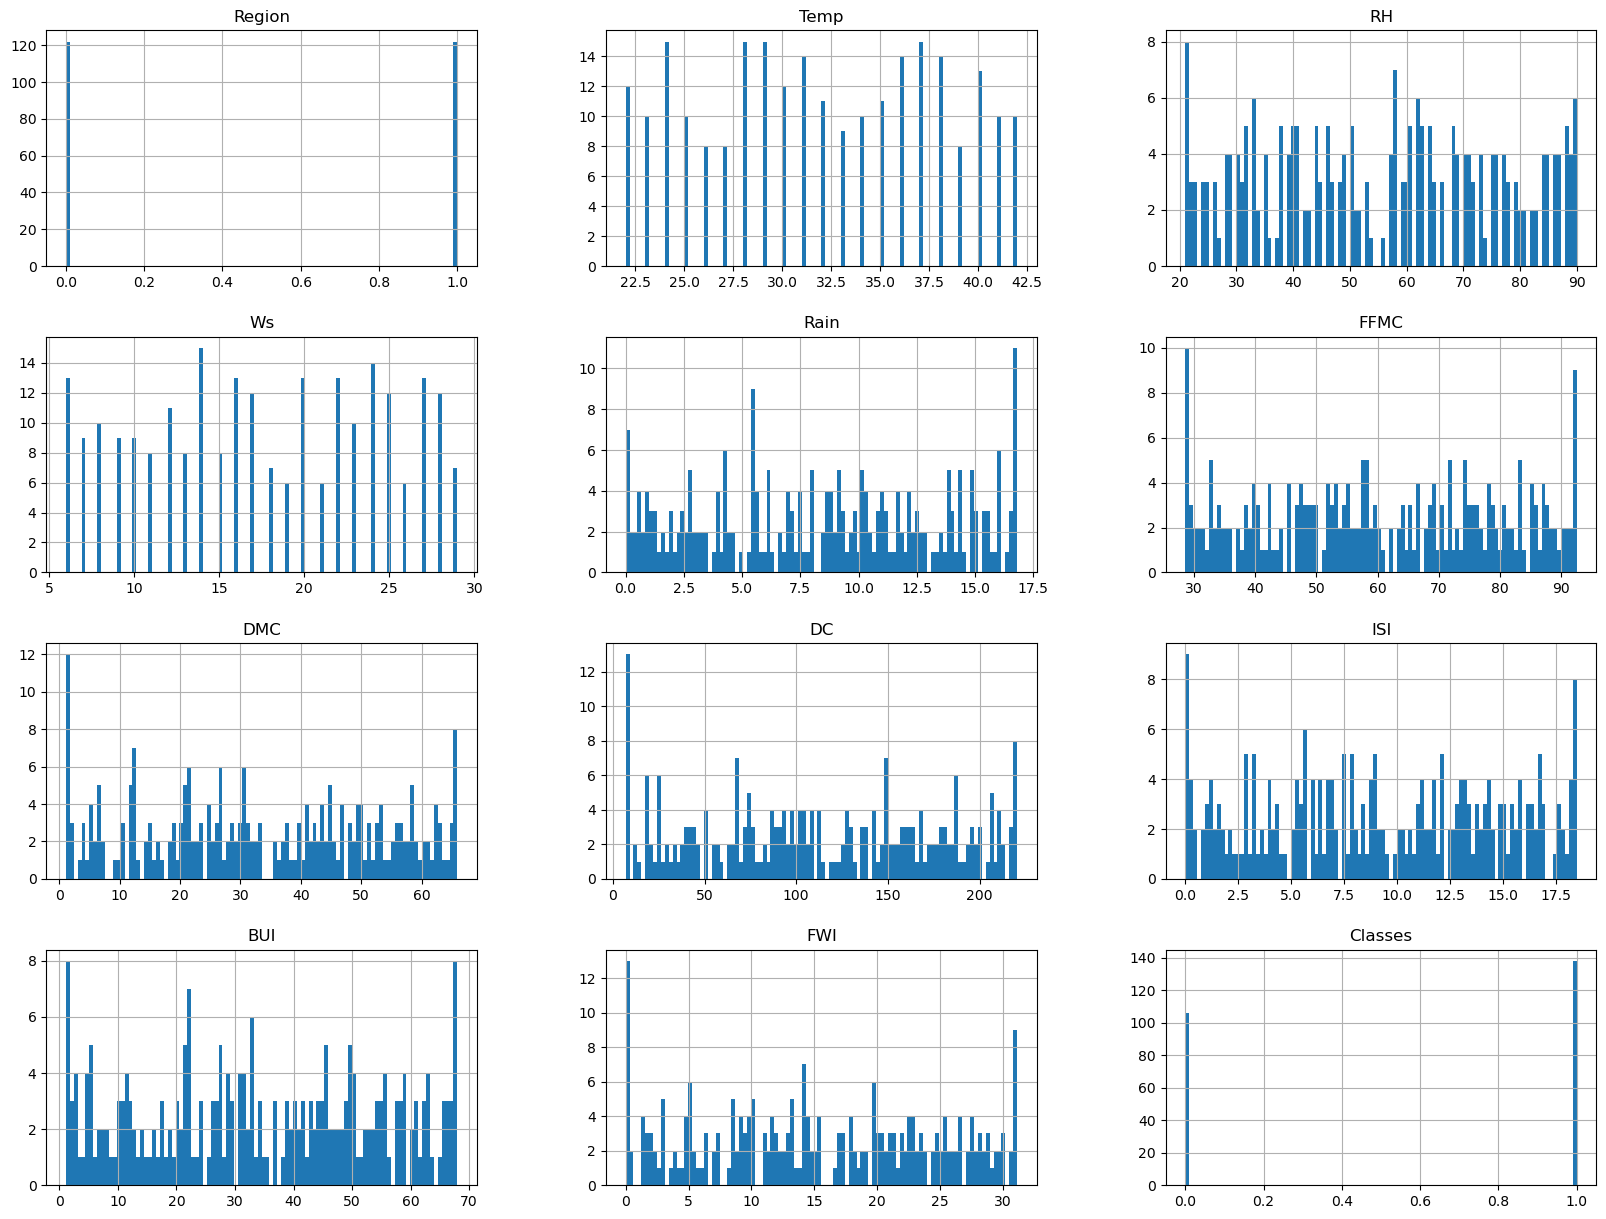

In [45]:
df_copy.hist(bins = 100, figsize=(20,15))
plt.show()

In [46]:
# Coorelation
df_copy.corr()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
Region,1.000000e+00,0.842923,-0.843347,0.843028,-0.836538,0.842795,0.844123,0.844091,0.841958,0.841160,0.843551,-5.048710e-17
Temp,8.429225e-01,1.000000,-0.988730,0.983951,-0.987641,0.991187,0.991376,0.991639,0.989580,0.991332,0.991782,-2.737734e-02
RH,-8.433475e-01,-0.988730,1.000000,-0.990100,0.993269,-0.997055,-0.997107,-0.997224,-0.995354,-0.996899,-0.997434,4.142556e-02
Ws,8.430282e-01,0.983951,-0.990100,1.000000,-0.988742,0.992890,0.993142,0.993365,0.991560,0.992412,0.993429,-4.268191e-02
Rain,-8.365381e-01,-0.987641,0.993269,-0.988742,1.000000,-0.994637,-0.994705,-0.994661,-0.991992,-0.994787,-0.995098,4.466999e-02
FFMC,8.427951e-01,0.991187,-0.997055,0.992890,-0.994637,1.000000,0.999107,0.999285,0.997221,0.998731,0.999522,-3.424093e-02
DMC,8.441229e-01,0.991376,-0.997107,0.993142,-0.994705,0.999107,1.000000,0.999297,0.997328,0.998717,0.999526,-3.615464e-02
DC,8.440905e-01,0.991639,-0.997224,0.993365,-0.994661,0.999285,0.999297,1.000000,0.997288,0.998989,0.999741,-3.681675e-02
ISI,8.419584e-01,0.989580,-0.995354,0.991560,-0.991992,0.997221,0.997328,0.997288,1.000000,0.996831,0.997618,-3.940796e-02
BUI,8.411599e-01,0.991332,-0.996899,0.992412,-0.994787,0.998731,0.998717,0.998989,0.996831,1.000000,0.999294,-3.733691e-02


<Axes: >

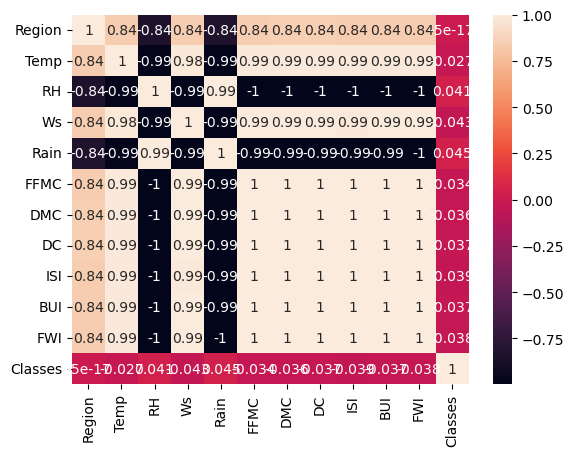

In [47]:
sns.heatmap(df_copy.corr(), annot=True)

In [48]:
df_copy

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,0
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,1
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,1
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,1


In [49]:
df2 = df_copy

In [50]:
df2

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
239,0,34,51,20,6.8,65.6,39.6,131.9,11.0,40.1,18.2,0
240,0,22,88,6,16.8,28.6,1.1,8.1,0.0,1.1,0.0,1
241,0,28,68,13,11.1,50.0,22.5,78.7,5.6,22.2,10.1,1
242,1,42,26,28,1.3,89.2,63.2,211.3,17.7,66.1,29.7,1


In [51]:
df2.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,0


In [52]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 23.0 KB


## Divide dataset into independent and dependent feature using multiple  linear regression

In [53]:
df2.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,1.8,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,4.7,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,20.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,29.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,25.4,0


In [54]:
x = df2.drop('FWI', axis=1)
y = df['FWI']

In [55]:
x.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
0,0,23,86,8,16.6,31.7,3.8,18.8,1.5,4.5,0
1,0,24,82,11,13.8,38.3,11.6,38.4,3.2,11.8,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,1
3,1,41,24,28,0.6,90.4,63.1,211.0,18.2,65.9,1
4,1,37,33,24,2.7,81.9,52.9,179.5,15.1,55.9,0


In [56]:
y.head()

0     1.8
1     4.7
2    20.2
3    29.9
4    25.4
Name: FWI, dtype: float64

## Divide the dataset into the train and test data

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.25, random_state=21)

In [59]:
x_train.head()

,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
203,1,36,47,20,7.0,70.4,43.4,149.5,12.2,44.4,0
2,1,36,48,22,6.1,69.1,42.7,146.5,12.6,44.2,1
95,0,25,77,11,13.9,40.4,12.6,47.2,3.2,12.0,1
42,0,35,43,22,5.6,71.8,44.7,148.4,12.0,46.1,0
13,1,40,32,27,1.9,82.0,56.7,187.7,15.9,58.0,0


In [60]:
x_train.shape

(183, 11)

In [61]:
x_test.shape

(61, 11)

In [62]:
y_train.shape

(183,)

In [63]:
y_test.shape

(61,)

In [64]:
x_train.corr()


,Region,Temp,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
Region,1.000000,0.847089,-0.848761,0.847462,-0.841048,0.848642,0.848989,0.850505,0.847261,0.847016,0.006832
Temp,0.847089,1.000000,-0.989514,0.984655,-0.987997,0.991977,0.991862,0.992407,0.990690,0.991863,-0.004097
RH,-0.848761,-0.989514,1.000000,-0.990216,0.993499,-0.997105,-0.997129,-0.997234,-0.995580,-0.996800,0.020643
Ws,0.847462,0.984655,-0.990216,1.000000,-0.989229,0.992807,0.993088,0.993422,0.991500,0.992600,-0.024215
Rain,-0.841048,-0.987997,0.993499,-0.989229,1.000000,-0.994923,-0.995264,-0.994966,-0.992105,-0.995042,0.015187
FFMC,0.848642,0.991977,-0.997105,0.992807,-0.994923,1.000000,0.999103,0.999295,0.997528,0.998771,-0.013113
DMC,0.848989,0.991862,-0.997129,0.993088,-0.995264,0.999103,1.000000,0.999338,0.997649,0.998674,-0.015657
DC,0.850505,0.992407,-0.997234,0.993422,-0.994966,0.999295,0.999338,1.000000,0.997582,0.998999,-0.016307
ISI,0.847261,0.990690,-0.995580,0.991500,-0.992105,0.997528,0.997649,0.997582,1.000000,0.997082,-0.016017
BUI,0.847016,0.991863,-0.996800,0.992600,-0.995042,0.998771,0.998674,0.998999,0.997082,1.000000,-0.015240


In [65]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)    
    return col_corr

In [66]:
corr_features =correlation(x_train, 0.97)


In [67]:
corr_features

{'BUI', 'DC', 'DMC', 'FFMC', 'ISI', 'RH', 'Rain', 'Ws'}

In [68]:
x_train.drop(corr_features, axis=1, inplace=True)

In [69]:
x_test.drop(corr_features,axis=1, inplace=True)


In [70]:
x_train.shape

(183, 3)

In [71]:
x_test.shape

(61, 3)

In [72]:
y_test.shape

(61,)

## Standard scaling on the train and test data

In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaller = StandardScaler()

In [75]:
x_train_scaled = scaller.fit_transform(x_train)

In [76]:
x_train_scaled

array([[ 1.01653005,  0.6388299 , -1.0856203 ],
       [ 1.01653005,  0.6388299 ,  0.92113237],
       [-0.98373875, -1.16476701,  0.92113237],
       [-0.98373875,  0.47486655, -1.0856203 ],
       [ 1.01653005,  1.29468333, -1.0856203 ],
       [-0.98373875, -0.50891358,  0.92113237],
       [-0.98373875, -0.34495023,  0.92113237],
       [ 1.01653005,  0.47486655,  0.92113237],
       [ 1.01653005,  1.13071997, -1.0856203 ],
       [ 1.01653005,  0.6388299 ,  0.92113237],
       [ 1.01653005, -0.18098687, -1.0856203 ],
       [-0.98373875, -1.00080365,  0.92113237],
       [-0.98373875, -0.67287694,  0.92113237],
       [-0.98373875, -0.18098687, -1.0856203 ],
       [ 1.01653005, -0.01702352, -1.0856203 ],
       [ 1.01653005,  1.62261004, -1.0856203 ],
       [ 1.01653005,  1.29468333, -1.0856203 ],
       [-0.98373875, -0.50891358,  0.92113237],
       [ 1.01653005,  1.13071997,  0.92113237],
       [ 1.01653005,  0.96675662,  0.92113237],
       [ 1.01653005,  1.13071997,  0.921

In [77]:
x_test_scaled = scaller.transform(x_test)


In [78]:
x_test_scaled

array([[-0.98373875, -0.8368403 ,  0.92113237],
       [-0.98373875, -1.65665707,  0.92113237],
       [-0.98373875, -0.50891358, -1.0856203 ],
       [ 1.01653005,  1.29468333,  0.92113237],
       [ 1.01653005,  0.47486655,  0.92113237],
       [ 1.01653005,  0.14693984,  0.92113237],
       [ 1.01653005,  0.80279326,  0.92113237],
       [ 1.01653005,  1.62261004,  0.92113237],
       [-0.98373875, -0.67287694,  0.92113237],
       [ 1.01653005,  1.13071997,  0.92113237],
       [ 1.01653005,  0.96675662, -1.0856203 ],
       [ 1.01653005,  0.31090319,  0.92113237],
       [-0.98373875, -1.16476701,  0.92113237],
       [ 1.01653005,  0.96675662, -1.0856203 ],
       [ 1.01653005,  0.80279326,  0.92113237],
       [ 1.01653005,  0.31090319, -1.0856203 ],
       [-0.98373875,  0.14693984, -1.0856203 ],
       [-0.98373875, -0.50891358,  0.92113237],
       [-0.98373875, -0.67287694,  0.92113237],
       [-0.98373875, -1.49269372, -1.0856203 ],
       [-0.98373875, -0.8368403 ,  0.921

In [79]:
x_train


,Region,Temp,Classes
203,1,36,0
2,1,36,1
95,0,25,1
42,0,35,0
13,1,40,0
...,...,...,...
48,1,39,0
4,1,37,0
56,1,37,0
207,0,28,1


## Train models

In [80]:
from sklearn.linear_model import LinearRegression

In [81]:
linreg = LinearRegression()

In [82]:
linreg.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
y_pred = linreg.predict(x_test_scaled)

In [84]:
y_pred

array([ 7.60300389,  0.04398198, 10.88003194, 27.86799169, 20.30896978,
       17.28536102, 23.33257854, 30.89160045,  9.11480827, 26.35618731,
       25.09780222, 18.7971654 ,  4.57939513, 25.09780222, 23.33257854,
       19.05058469, 16.92724947, 10.62661265,  9.11480827,  1.80920566,
        7.60300389, 13.90364071,  1.55578636, 12.13841703, 20.56238907,
       15.41544509, 16.02697593, 23.33257854, 20.30896978, 23.33257854,
       10.88003194, 31.14501974, 22.07419345, 23.58599783,  0.29740127,
       10.62661265,  4.57939513,  3.06759074,  1.80920566,  0.04398198,
        0.29740127,  6.09119951, 20.30896978, 17.28536102, 15.77355664,
       17.28536102, 18.7971654 , 18.7971654 , 24.84438292, 22.07419345,
       25.09780222, 16.02697593, 21.82077416, 12.13841703, 12.13841703,
        9.36822756,  9.11480827, 29.63321536, 17.28536102,  3.06759074,
        7.60300389])

In [85]:
y_test

173     9.7
240     0.0
243    12.2
175    27.1
162    20.5
       ... 
178     9.2
230    28.5
193    15.0
87      2.1
158     8.6
Name: FWI, Length: 61, dtype: float64

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [87]:
mae = mean_absolute_error(y_test, y_pred)

In [88]:
mae

1.0146729835916988

In [89]:
from sklearn.metrics import r2_score

In [90]:
score = r2_score(y_test,y_pred)

In [91]:
score

0.9785218145381228

## Lasso Regression

In [92]:
from sklearn.linear_model import Lasso

In [93]:
lasso = Lasso()

In [94]:
lasso.fit(x_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [95]:
y_pred = lasso.predict(x_test_scaled)

In [96]:
y_pred

array([ 8.63976639,  1.68782448, 11.42054316, 26.71481537, 19.76287346,
       16.98209669, 22.54365023, 29.49559214, 10.03015478, 25.32442699,
       23.93403861, 18.37248508,  5.85898963, 23.93403861, 22.54365023,
       18.37248508, 16.98209669, 11.42054316, 10.03015478,  3.07821286,
        8.63976639, 14.20131993,  3.07821286, 12.81093154, 19.76287346,
       15.59170831, 15.59170831, 22.54365023, 19.76287346, 22.54365023,
       11.42054316, 29.49559214, 21.15326184, 22.54365023,  1.68782448,
       11.42054316,  5.85898963,  4.46860125,  3.07821286,  1.68782448,
        1.68782448,  7.24937801, 19.76287346, 16.98209669, 15.59170831,
       16.98209669, 18.37248508, 18.37248508, 23.93403861, 21.15326184,
       23.93403861, 15.59170831, 21.15326184, 12.81093154, 12.81093154,
       10.03015478, 10.03015478, 28.10520376, 16.98209669,  4.46860125,
        8.63976639])

In [97]:
y_test

173     9.7
240     0.0
243    12.2
175    27.1
162    20.5
       ... 
178     9.2
230    28.5
193    15.0
87      2.1
158     8.6
Name: FWI, Length: 61, dtype: float64

In [98]:
mae = mean_absolute_error(y_test,y_pred)

In [99]:
mae

1.3481220771535323

In [100]:
score = r2_score(y_test,y_pred)

In [101]:
score

0.9665875946021096

## Ridge Regression Model

In [102]:
from sklearn.linear_model import Ridge

In [103]:
ridge = Ridge()

In [104]:
ridge.fit(x_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [105]:
y_pred = ridge.predict(x_test_scaled)

In [106]:
y_pred

array([ 7.60511152,  0.18371565, 10.82899058, 27.79186193, 20.37046606,
       17.40190771, 23.33902441, 30.76042028,  9.0893907 , 26.30758276,
       25.0786243 , 18.88618688,  4.63655317, 25.0786243 , 23.33902441,
       19.1415076 , 16.76610728, 10.57366987,  9.0893907 ,  1.92331553,
        7.60511152, 13.79754893,  1.66799482, 12.05794905, 20.62578677,
       15.28182811, 16.17294925, 23.33902441, 20.37046606, 23.33902441,
       10.82899058, 31.015741  , 22.11006595, 23.59434512,  0.43903636,
       10.57366987,  4.63655317,  3.152274  ,  1.92331553,  0.18371565,
        0.43903636,  6.12083235, 20.37046606, 17.40190771, 15.91762853,
       17.40190771, 18.88618688, 18.88618688, 24.82330358, 22.11006595,
       25.0786243 , 16.17294925, 21.85474523, 12.05794905, 12.05794905,
        9.34471141,  9.0893907 , 29.53146182, 17.40190771,  3.152274  ,
        7.60511152])

In [107]:
y_test

173     9.7
240     0.0
243    12.2
175    27.1
162    20.5
       ... 
178     9.2
230    28.5
193    15.0
87      2.1
158     8.6
Name: FWI, Length: 61, dtype: float64

In [108]:
mae= mean_absolute_error(y_test, y_pred)

In [109]:
mae

1.0261734140974481

In [110]:
score = r2_score(y_test, y_pred)

In [111]:
score

0.9781555685609113

## Elastic net regression model

In [112]:
from sklearn.linear_model import ElasticNet

In [113]:
elasticnet = ElasticNet()

In [114]:
elasticnet.fit(x_train_scaled, y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [115]:
y_pred = elasticnet.predict(x_test_scaled)

In [116]:
y_pred

array([ 9.45327325,  5.69836094, 10.95523818, 24.19752721, 20.44261489,
       18.94064997, 21.94457982, 25.69949213, 10.20425572, 23.44654474,
       22.69556228, 19.69163243,  7.95130833, 22.69556228, 21.94457982,
       19.69163243, 13.95916803, 10.95523818, 10.20425572,  6.4493434 ,
        9.45327325, 12.4572031 ,  6.4493434 , 11.70622064, 20.44261489,
       13.20818557, 18.18966751, 21.94457982, 20.44261489, 21.94457982,
       10.95523818, 25.69949213, 21.19359736, 21.94457982,  5.69836094,
       10.95523818,  7.95130833,  7.20032587,  6.4493434 ,  5.69836094,
        5.69836094,  8.70229079, 20.44261489, 18.94064997, 18.18966751,
       18.94064997, 19.69163243, 19.69163243, 22.69556228, 21.19359736,
       22.69556228, 18.18966751, 21.19359736, 11.70622064, 11.70622064,
       10.20425572, 10.20425572, 24.94850967, 18.94064997,  7.20032587,
        9.45327325])

In [117]:
y_test

173     9.7
240     0.0
243    12.2
175    27.1
162    20.5
       ... 
178     9.2
230    28.5
193    15.0
87      2.1
158     8.6
Name: FWI, Length: 61, dtype: float64

In [118]:
mae = mean_absolute_error(y_test, y_pred)  

In [119]:
mae

2.4358553171944473

In [120]:
score = r2_score(y_test, y_pred)


In [121]:
score

0.8764622672580478

## Create pkl file


In [122]:
import pickle
pickle.dump(scaller, open('scaler.pkl','wb'))
pickle.dump(ridge, open('rigde.pkl','wb'))

In [123]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Region   244 non-null    int64  
 1   Temp     244 non-null    int64  
 2   RH       244 non-null    int64  
 3   Ws       244 non-null    int64  
 4   Rain     244 non-null    float64
 5   FFMC     244 non-null    float64
 6   DMC      244 non-null    float64
 7   DC       244 non-null    float64
 8   ISI      244 non-null    float64
 9   BUI      244 non-null    float64
 10  FWI      244 non-null    float64
 11  Classes  244 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 23.0 KB


In [124]:
df2.columns

Index(['Region', 'Temp', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes'],
      dtype='object')